In [1]:
import gymnasium as gym
import numpy as np
import random
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt

In [2]:
# 1. Definice architektury sítě
# Vstupy: 2 (pozice, rychlost)
# Skrytá vrstva: 16 neuronů
# Výstupy: 3 (vlevo, nic, vpravo)
# Počet vah: (2 * 16) + 16 biasů + (16 * 3) + 3 biasy = 32 + 16 + 48 + 3 = 99
NUM_WEIGHTS = 99
POS_WEIGHT = 100 # Jak moc je pozice dulezita pro fitness




In [3]:
# Deap setup
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()


toolbox.register("attr_float", random.uniform, -1.0, 1.0)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, n=NUM_WEIGHTS)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# vse vlastne v defaultnim nastaveni
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=0.5, indpb=0.1)
toolbox.register("select", tools.selTournament, tournsize=3)

hof = tools.HallOfFame(1)

In [4]:
def forward_pass(obs, weights):
    W1 = np.array(weights[:32]).reshape(2, 16)
    b1 = np.array(weights[32:48])
    W2 = np.array(weights[48:96]).reshape(16, 3)
    b2 = np.array(weights[96:])

    # Tanh je aktivacni funkce pro skrytou vrstvu
    hidden = np.tanh( np.dot(obs, W1) + b1)
    
    
    output = np.dot(hidden, W2) + b2

    # Akce je index neuronu s nejvyšší hodnotou 
    return int(np.argmax(output))


def evaluate(individual):
    env = gym.make('MountainCar-v0')
    obs, info = env.reset()
    
    total_reward = 0
    max_position = -np.inf

    terminated = False
    truncated = False

    while not (terminated or truncated):
        # Síť rozhodne o akci na základě aktuálního stavu
        action = forward_pass(obs, individual)
        
        # 2. Provedení akce v prostředí
        obs, reward, terminated, truncated, info = env.step(action)

        if reward == 1:
            reward += 100 # Bonus za dosažení cíle
         # Penalizace za krok bez pokroku
        total_reward += reward
        
        # Zaznamenání nejvyšší dosažené pozice pro lepší fitness
        if obs[0] > max_position:
            max_position = obs[0]

    env.close()

    fitness = total_reward + (max_position * POS_WEIGHT)
    
    return fitness,

toolbox.register("evaluate", evaluate)


def animate(individual):
    env = gym.make('MountainCar-v0', render_mode='human')
    obs, info = env.reset()
    
    terminated = False
    truncated = False

    while not (terminated or truncated):
        action = forward_pass(obs, individual)
        obs, reward, terminated, truncated, info = env.step(action)

    env.close()


In [5]:

pop = toolbox.population(n=50)
    
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("max", np.max)

pop, logbook = algorithms.eaSimple(pop, toolbox ,cxpb=0.2, mutpb=0.5, ngen=50, stats=stats, halloffame=hof, verbose=True)

# Nalezení nejlepšího jedince
best_ind = hof[0]


print(f"\nEvoluce dokončena!")
print(f"Fitness nejlepšího jedince: {best_ind.fitness.values[0]}")
animate(best_ind)

gen	nevals	avg               	max               
0  	50    	-239.5145263671875	-216.8749542236328
1  	34    	-232.48989868164062	-216.8749542236328
2  	37    	-229.64642333984375	-215.11485290527344
3  	25    	-224.28646850585938	-215.11485290527344
4  	29    	-224.51783752441406	-215.41238403320312
5  	35    	-225.05010986328125	-172.48289489746094
6  	32    	-224.65283203125   	-172.48289489746094
7  	31    	-225.97975158691406	-172.48289489746094
8  	28    	-220.42674255371094	-172.48289489746094
9  	30    	-216.47140502929688	-61.389976501464844
10 	29    	-213.98568725585938	-61.389976501464844
11 	24    	-214.14085388183594	-61.389976501464844
12 	26    	-215.46603393554688	-61.389976501464844
13 	27    	-208.1658935546875 	-61.389976501464844
14 	29    	-213.44041442871094	-61.389976501464844
15 	28    	-207.77914428710938	-59.57079315185547 
16 	34    	-204.3450164794922 	-59.57079315185547 
17 	37    	-213.56948852539062	-59.57079315185547 
18 	34    	-216.7230682373047 	-59.5

# Mountain Car

## Prostředí
Vyzkoušel jsem řešit problém MountainCar.

## Algoritmus a jeho nastavení
Neuronky jsem definoval jako 1D `array` a problém jsem řešil evolucí vah, protože jsem nechtěl oba dva problémy dělat přes NEAT. 

Využil jsem klasický evoluční algoritmus z balíčku deap (`eaSimple`), který má "jasně dané" defaultní hyperparametry. Plánoval jsem dělat custom Hof a podobně, ale na tento problém to nebylo třeba. 

### Hyperparametry

- cxpb: Pravděpodobnost páření jsem snížil na 0.2, protože jsem si pamatoval z přednášky/cvika, že to je problémová část evoluce vah. Zkusil jsem i $cxpb=0.0$, ale fitness generací mi vždy velmi stagnovali. Takže páření v mé evoluci má spíš explorační funkci.
- mutpb: Z "defaultní hodnoty" 0.7  jsem ho srazil na 0.5 (na začátku kódování) a od té doby jsem na něj nesahal, protože jsem neviděl důvod ho měnit (zlatá střední cesta)
- ngen a počet jedinců v populaci: Ty jsem nastavoval jako poslední. V moment kdy jsem viděl že 20 generace je mnohem lepší než první, postupně jsem navyšoval počet generací, než na konci vždy auto dojelo do cíle. Počet jedinců jsem nastavil na 50, protože pro <50  mi mutace ani páření "negenerovalo" požadovanou exploraci.
- POS_WEIGHT: Nastaveno na 100 aby byl rozdíl mezi fitnessem aut, které se dostanou dál od cíle, přestože nedojedou do cíle.



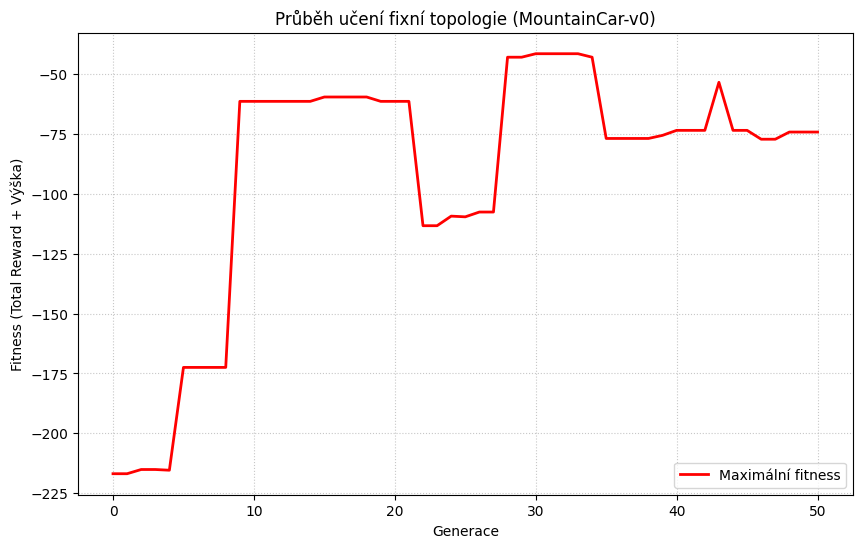

In [ ]:
generace = logbook.select("gen")
max_fitness = logbook.select("max")
plt.figure(figsize=(10, 6))

plt.plot(generace, max_fitness, label="Maximální fitness", color="red", linewidth=2)
plt.title("Průběh učení fixní topologie (MountainCar-v0)")
plt.xlabel("Generace")
plt.ylabel("Fitness (Total Reward + Výška)")
plt.legend(loc="lower right")
plt.grid(True, linestyle=":", alpha=0.7)
plt.savefig("mountaincar_deap_fitness.png")
plt.show()